# 05 · Interpretabilidad con Grad-CAM

Grad-CAM explica al **modelo**, no a la mariposa: muestra qué regiones movieron
la predicción, no qué rasgos distinguen a la especie.

Este notebook no se queda en el panel cualitativo. `ButterflyDataset` guardó la
caja de detección de YOLO-World de cada imagen (`auditoria.csv`), así que se
puede **medir** qué fracción de la activación cae sobre el ejemplar. La
comparación no es contra cero sino contra el área de la caja: la mariposa ocupa
~51% del recorte, así que una atención repartida al azar daría ~0.51. Solo lo
que exceda eso es evidencia de que el modelo mira al animal.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "corpus.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image

from scripts import corpus
from scripts import modelRegistry as registro
from scripts.architectures import gradcamLayer, preprocessFn
from scripts.gradcam import (areaCaja, cajaEnRecorte, computeGradcam,
                             fraccionDentro, overlayHeatmap)
from scripts.vizStyle import (INK_MUTED, SERIE_1, SERIE_2, SERIE_3, applyStyle,
                              limpiarEje)

MUESTRA = 150       # imágenes de test para la parte cuantitativa
SEMILLA = 42

corpus.materializar()
clases = corpus.classNames()

auditoria = pd.read_csv(Path(corpus.loadConfig()["dataset_dir"]).parent / "auditoria.csv")
auditoria = auditoria[(auditoria.veredicto == "aceptada") & (auditoria.split == "test")]
print(f"{len(auditoria)} imágenes de test con caja de detección")

2062 imágenes de test con caja de detección


## 1 · Los dos modelos a comparar

El estudiante es el que se despliega, así que sus explicaciones son las que el
usuario va a ver. El docente sirve de referencia: ¿el modelo más preciso mira
mejor evidencia, o solo aprovecha más capacidad?

In [3]:
MODELOS = {}
for rol, archivo in (("estudiante", "student.json"), ("docente", "teacher.json")):
    info = registro.readJson(registro.OUTPUTS_DIR / archivo)
    if info is None:
        print(f"Falta outputs/{archivo}")
        continue
    MODELOS[rol] = {
        "arquitectura": info["architecture"],
        "modelo": tf.keras.models.load_model(registro.rutaModelo(info["run_id"])),
        "capa": gradcamLayer(info["architecture"]),
        "preprocess": preprocessFn(info["architecture"]),
        "f1": info["test_macro_f1"],
    }

pd.DataFrame([{
    "rol": rol, "arquitectura": m["arquitectura"], "capa_gradcam": m["capa"],
    "macro_f1": round(m["f1"], 4),
    "resolucion_mapa": tuple(m["modelo"].get_layer(m["capa"]).output.shape[1:3]),
} for rol, m in MODELOS.items()])

,rol,arquitectura,capa_gradcam,macro_f1,resolucion_mapa
0,estudiante,mobilenet_v3_small,conv_1,0.8426,"(10, 10)"
1,docente,efficientnet_v2_s,top_activation,0.9135,"(10, 10)"


## 2 · Panel cualitativo

Para cada especie se toma la predicción correcta más confiada del estudiante, y
se explica **la clase predicha** en ambos modelos sobre la misma imagen.

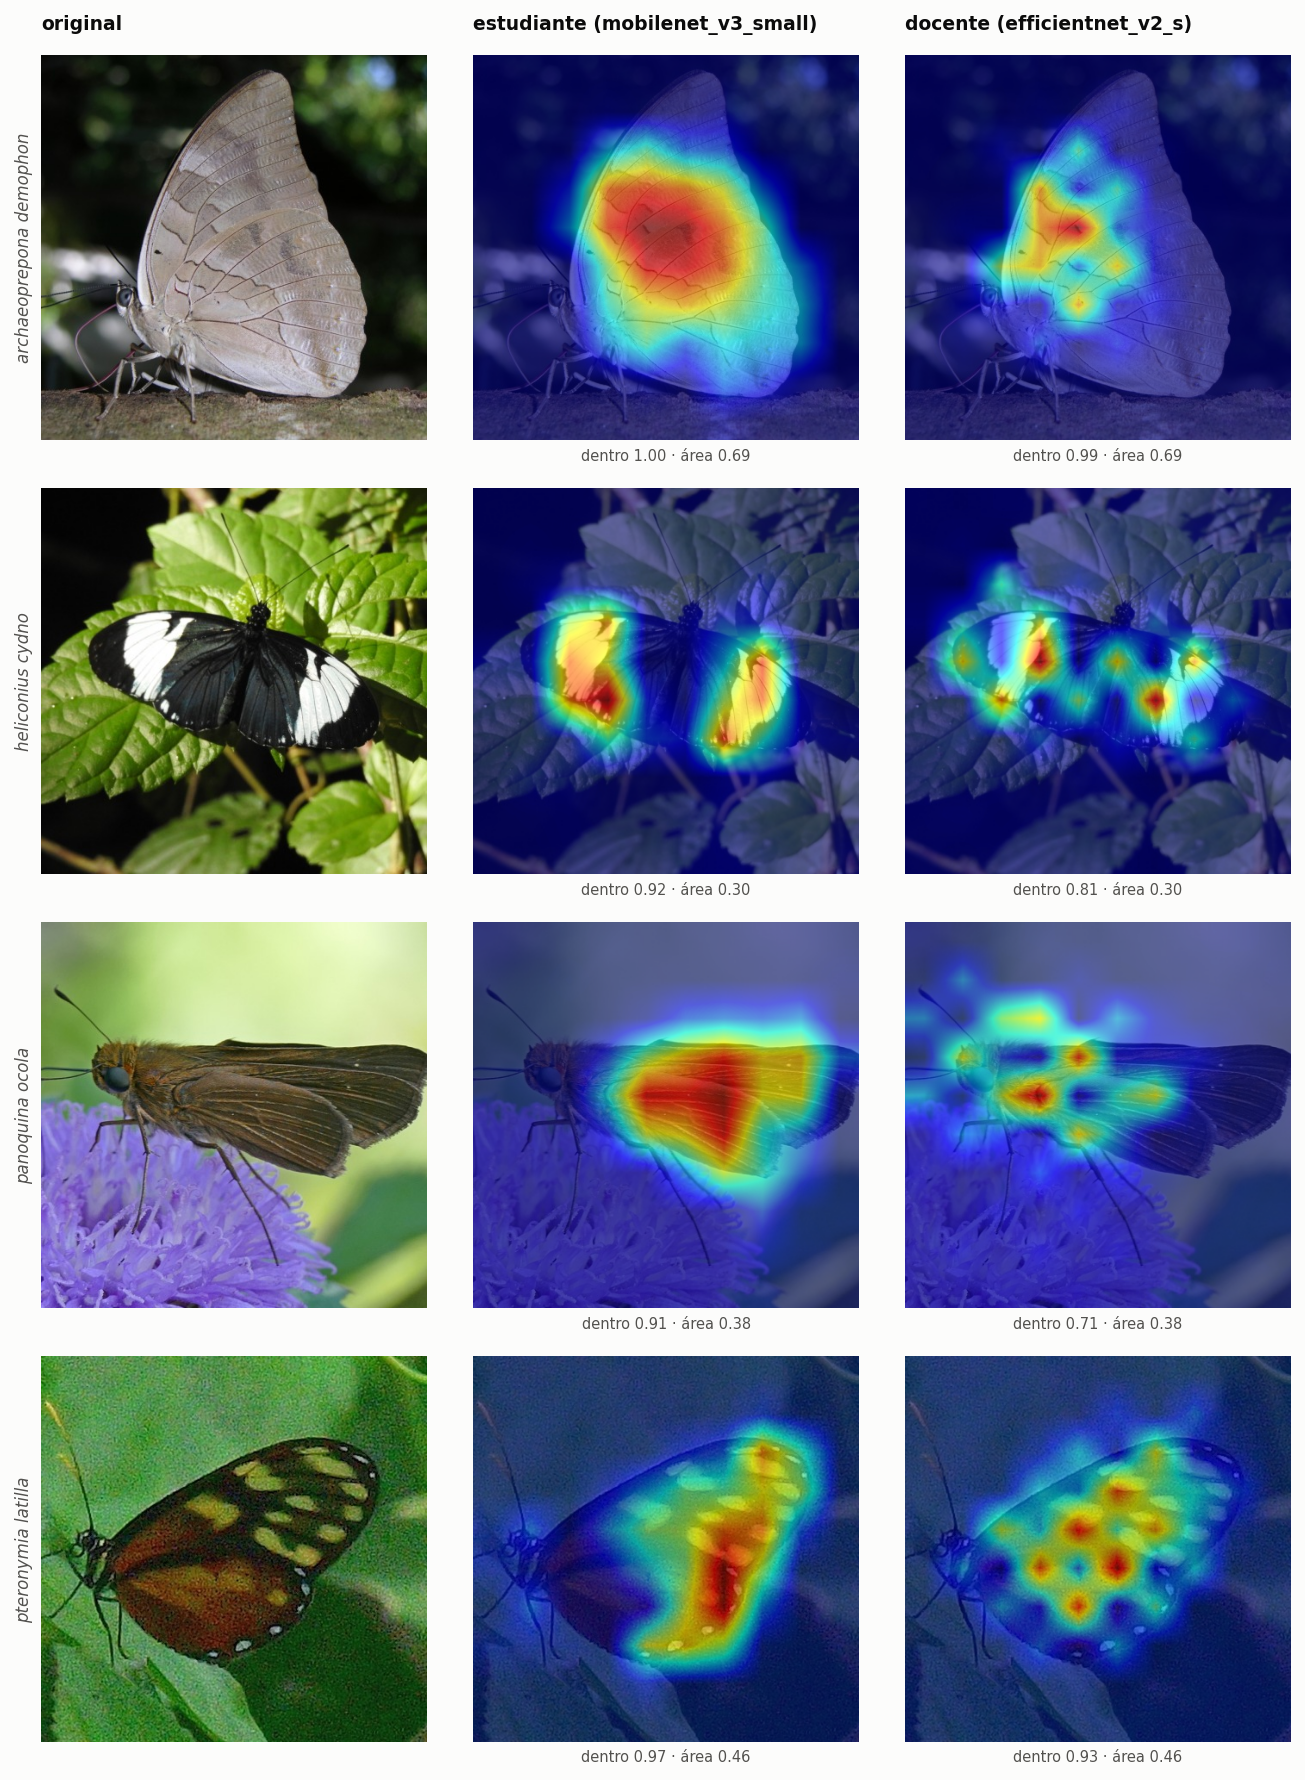

In [4]:
def rutaTest(archivo):
    especie = "_".join(archivo.split("_")[:-1])
    return Path("dataset/test") / especie / archivo


def predecir(m, img):
    arr = np.asarray(img.convert("RGB").resize(
        (m["modelo"].input_shape[2], m["modelo"].input_shape[1])), dtype=np.float32)
    probs = m["modelo"].predict(m["preprocess"](arr[None]), verbose=0)[0]
    return int(np.argmax(probs)), float(np.max(probs))


rng = np.random.default_rng(SEMILLA)
especiesPanel = sorted(rng.choice(clases, 4, replace=False))

filas = []
for especie in especiesPanel:
    candidatas = auditoria[auditoria.especie == especie]
    mejor = None
    for _, fila in candidatas.iterrows():
        img = Image.open(rutaTest(fila["archivo"]))
        idx, conf = predecir(MODELOS["estudiante"], img)
        if clases[idx] == especie and (mejor is None or conf > mejor[1]):
            mejor = (fila, conf, img, idx)
    if mejor is None:   # sin acierto: se muestra el error más confiado
        fila = candidatas.iloc[0]
        img = Image.open(rutaTest(fila["archivo"]))
        idx, conf = predecir(MODELOS["estudiante"], img)
        mejor = (fila, conf, img, idx)
    filas.append((especie, *mejor))

applyStyle()
fig, ejes = plt.subplots(len(filas), 3, figsize=(9, 3 * len(filas)))
for f, (especie, fila, conf, img, idx) in enumerate(filas):
    caja = cajaEnRecorte(fila)
    ejes[f, 0].imshow(img)
    limpiarEje(ejes[f, 0])
    ejes[f, 0].set_ylabel(especie.replace("_", " "), fontsize=8, style="italic")
    if f == 0:
        ejes[f, 0].set_title("original", fontsize=9)
    for k, rol in enumerate(("estudiante", "docente"), start=1):
        m = MODELOS[rol]
        mapa = computeGradcam(m["modelo"], img, idx, m["capa"], m["preprocess"])
        ejes[f, k].imshow(overlayHeatmap(img, mapa))
        limpiarEje(ejes[f, k])
        ejes[f, k].set_xlabel(f"dentro {fraccionDentro(mapa, caja):.2f} · área {areaCaja(caja):.2f}",
                              fontsize=7)
        if f == 0:
            ejes[f, k].set_title(f"{rol} ({m['arquitectura']})", fontsize=9)
fig.tight_layout()
plt.show()

## 3 · ¿Mira al ejemplar? La medición

Se calcula sobre una muestra del test. `dentro` es la fracción de activación
que cae en la caja; `area` es la misma fracción si la atención fuera uniforme.
La diferencia entre ambas es lo único que sostiene la afirmación "el modelo
mira la mariposa".

In [5]:
muestra = auditoria.sample(min(MUESTRA, len(auditoria)), random_state=SEMILLA)

registros = []
for _, fila in muestra.iterrows():
    img = Image.open(rutaTest(fila["archivo"]))
    caja = cajaEnRecorte(fila)
    area = areaCaja(caja)
    if area <= 0:
        continue
    for rol, m in MODELOS.items():
        idx, conf = predecir(m, img)
        mapa = computeGradcam(m["modelo"], img, idx, m["capa"], m["preprocess"])
        registros.append({
            "rol": rol,
            "especie": fila["especie"],
            "acierto": clases[idx] == fila["especie"],
            "confianza": conf,
            "dentro": fraccionDentro(mapa, caja),
            "area": area,
        })

atencion = pd.DataFrame(registros).dropna(subset=["dentro"])
atencion["exceso"] = atencion["dentro"] - atencion["area"]

resumen = atencion.groupby("rol").agg(
    n=("dentro", "size"),
    dentro_media=("dentro", "mean"),
    area_media=("area", "mean"),
    exceso_medio=("exceso", "mean"),
    exceso_mediano=("exceso", "median"),
).round(4)
print(resumen.to_string())
print()
for rol, g in atencion.groupby("rol"):
    frac = (g["exceso"] > 0).mean()
    print(f"  {rol:11} concentra por encima del azar en {frac:.1%} de las imágenes")

              n  dentro_media  area_media  exceso_medio  exceso_mediano
rol                                                                    
docente     150        0.9042      0.5229        0.3813          0.4098
estudiante  150        0.8510      0.5229        0.3282          0.3894

  docente     concentra por encima del azar en 98.7% de las imágenes
  estudiante  concentra por encima del azar en 93.3% de las imágenes


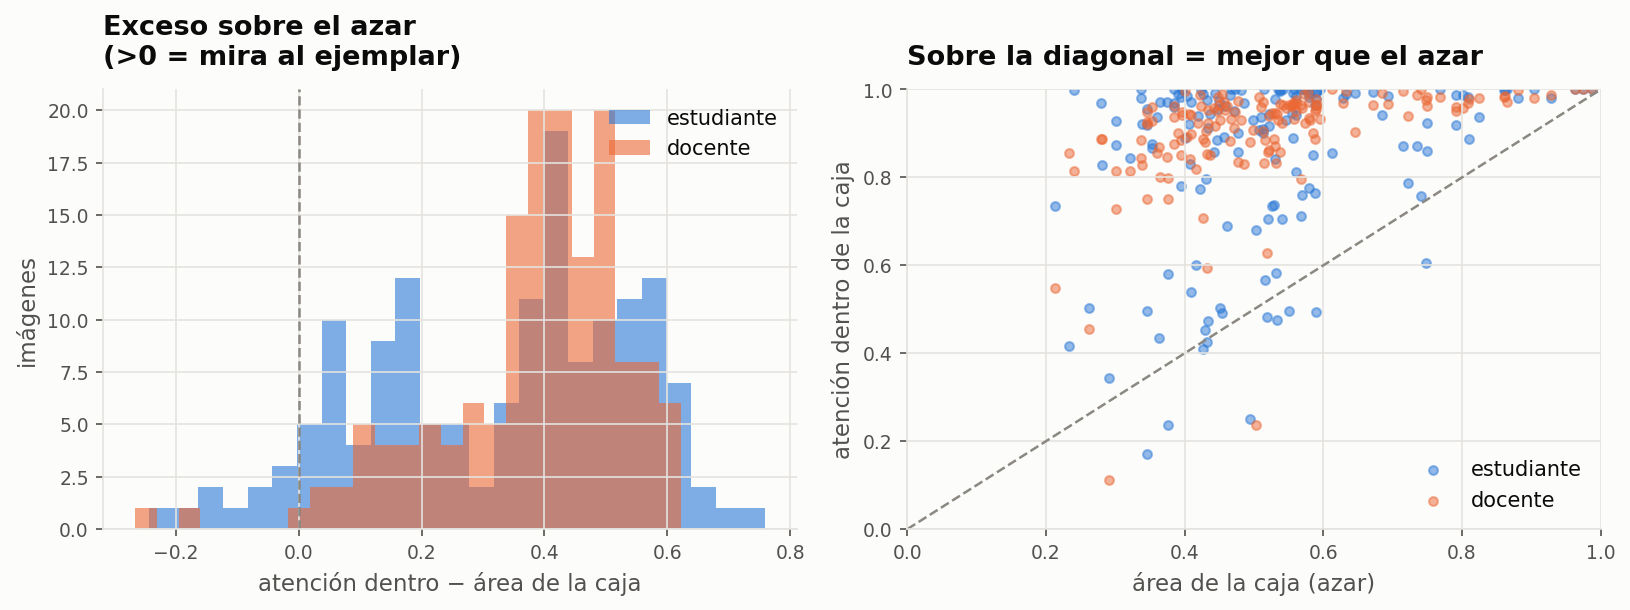

In [6]:
applyStyle()
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))

for rol, color in (("estudiante", SERIE_1), ("docente", SERIE_2)):
    g = atencion[atencion["rol"] == rol]
    ejes[0].hist(g["exceso"], bins=25, alpha=0.6, color=color, label=rol)
ejes[0].axvline(0, color=INK_MUTED, linestyle="--", linewidth=1.2)
ejes[0].set(xlabel="atención dentro − área de la caja", ylabel="imágenes",
            title="Exceso sobre el azar\n(>0 = mira al ejemplar)")
ejes[0].legend()

for rol, color in (("estudiante", SERIE_1), ("docente", SERIE_2)):
    g = atencion[atencion["rol"] == rol]
    ejes[1].scatter(g["area"], g["dentro"], s=18, alpha=0.5, color=color, label=rol)
lim = [0, 1]
ejes[1].plot(lim, lim, color=INK_MUTED, linestyle="--", linewidth=1.2)
ejes[1].set(xlim=lim, ylim=lim, xlabel="área de la caja (azar)",
            ylabel="atención dentro de la caja",
            title="Sobre la diagonal = mejor que el azar")
ejes[1].legend(loc="lower right")

fig.tight_layout()
plt.show()

## 4 · ¿Mira peor cuando se equivoca?

Si la atención cae fuera del ejemplar justo en los errores, Grad-CAM sirve como
señal de baja confiabilidad y no solo como ilustración.

In [7]:
porAcierto = atencion.groupby(["rol", "acierto"]).agg(
    n=("exceso", "size"),
    exceso_medio=("exceso", "mean"),
    confianza_media=("confianza", "mean"),
).round(4)
print(porAcierto.to_string())

print()
for rol, g in atencion.groupby("rol"):
    ok, mal = g[g["acierto"]]["exceso"], g[~g["acierto"]]["exceso"]
    if len(mal) >= 5:
        print(f"  {rol:11} exceso en aciertos {ok.mean():+.4f} vs errores {mal.mean():+.4f} "
              f"(diferencia {ok.mean() - mal.mean():+.4f}, n_errores={len(mal)})")
    else:
        print(f"  {rol:11} solo {len(mal)} errores en la muestra: insuficiente para comparar")

                      n  exceso_medio  confianza_media
rol        acierto                                    
docente    False     16        0.2914           0.8088
           True     134        0.3920           0.9845
estudiante False     31        0.2601           0.6062
           True     119        0.3459           0.9361

  docente     exceso en aciertos +0.3920 vs errores +0.2914 (diferencia +0.1006, n_errores=16)
  estudiante  exceso en aciertos +0.3459 vs errores +0.2601 (diferencia +0.0858, n_errores=31)


## 5 · Confusiones intra-género

El modo de error dominante son especies del mismo género. Aquí se ve qué mira
el estudiante cuando confunde dos congéneres.

In [8]:
info = registro.readJson(registro.OUTPUTS_DIR / "student.json")
metricas = registro.loadRunMetrics(info["run_id"])["splits"]["test"]
matriz = np.array(metricas["confusion_matrix"])
nombres = metricas["class_names"]

pares = [
    {"real": nombres[i], "predicha": nombres[j], "casos": int(matriz[i][j])}
    for i in range(len(nombres)) for j in range(len(nombres))
    if i != j and matriz[i][j] > 0 and nombres[i].split("_")[0] == nombres[j].split("_")[0]
]
pares = sorted(pares, key=lambda p: -p["casos"])[:3]
pd.DataFrame(pares)

,real,predicha,casos
0,mechanitis_lysimnia,mechanitis_menapis,11
1,parides_erithalion,parides_eurimedes,11
2,urbanus_procne,urbanus_simplicius,11


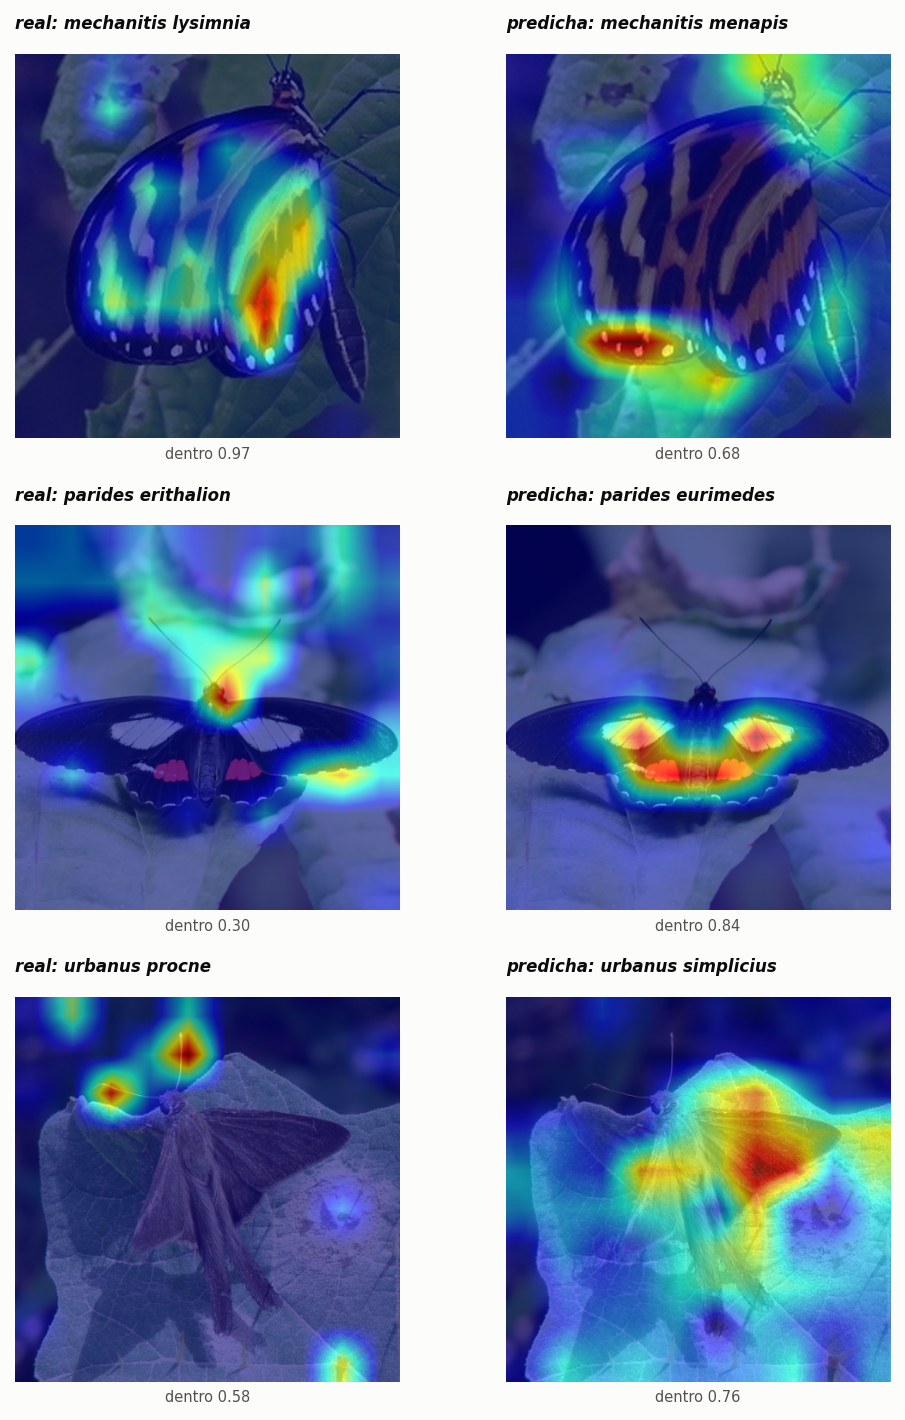

In [9]:
applyStyle()
m = MODELOS["estudiante"]
fig, ejes = plt.subplots(len(pares), 2, figsize=(7, 3.2 * len(pares)))
ejes = np.atleast_2d(ejes)

for f, par in enumerate(pares):
    fila = auditoria[auditoria.especie == par["real"]].iloc[0]
    img = Image.open(rutaTest(fila["archivo"]))
    caja = cajaEnRecorte(fila)
    for k, (etiqueta, especie) in enumerate((("real", par["real"]), ("predicha", par["predicha"]))):
        mapa = computeGradcam(m["modelo"], img, clases.index(especie), m["capa"], m["preprocess"])
        ejes[f, k].imshow(overlayHeatmap(img, mapa))
        limpiarEje(ejes[f, k])
        ejes[f, k].set_title(f"{etiqueta}: {especie.replace('_', ' ')}", fontsize=8, style="italic")
        ejes[f, k].set_xlabel(f"dentro {fraccionDentro(mapa, caja):.2f}", fontsize=7)
fig.tight_layout()
plt.show()

## Lo que esto sí y no permite afirmar

**Sí**: cuánta de la activación cae sobre el ejemplar frente a lo que daría el
azar, medido sobre una muestra del test y no sobre una imagen elegida a mano.

**No**: que las regiones resaltadas sean los rasgos taxonómicos que usa un
especialista. La caja de YOLO-World acota al animal completo, no a la venación
ni a los ocelos, así que "dentro de la caja" no equivale a "mirando el rasgo
diagnóstico".

**Límite de resolución**: los mapas salen de la última capa convolucional, de
10x10 para una entrada de 320x320. Cada celda cubre 32 píxeles, así que la
localización es gruesa por construcción — Grad-CAM++ o capas intermedias darían
más detalle.